In [24]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

#Load existing dataset from CSV if it exists, otherwise create it from intial data 
#Return both the full dataframe and numpy arrays (x inputs, y outputs)
csv_path = Path("function_5_data.csv")

def load_or_create_dataset():
    if csv_path.exists():
        df = pd.read_csv(csv_path)
    else:
        X_init = np.load('../data/initial_data/function_5/initial_inputs.npy')
        y_init = np.load('../data/initial_data/function_5/initial_outputs.npy')

        df = pd.DataFrame(X_init, columns=['x1', 'x2', 'x3', 'x4'])
        df['y'] = y_init
        df.to_csv(csv_path, index=False)

    X = df[['x1', 'x2', 'x3', 'x4']].to_numpy()
    y = df['y'].to_numpy()

    return df, X, y

df, X, y = load_or_create_dataset()


#checking shape of data 
print('Inputs Shape:', X.shape)
print('Outputs Shape:', y.shape)


Inputs Shape: (30, 4)
Outputs Shape: (30,)


In [30]:
#Append newly observed datapoints to existing CSV to keep a single up to date dataset

#Create a function to do this
def append_bo_result(x_new, y_new):
    df = pd.read_csv(csv_path)
    new_row = pd.DataFrame([[x_new[0], x_new[1], x_new[2], x_new[3], y_new]], columns=df.columns)
    df = pd.concat([df, new_row], ignore_index=True)
    df.to_csv(csv_path, index=False)
    return df

#Adding new values to my CSV df
#x_new = [0.999999, 0.999999, 0.999999, 0.999999]	
#y_new = 8662.405001248297

#df = append_bo_result(x_new, y_new)

# Refresh X and y from the updated live dataframe
X = df[['x1', 'x2', 'x3', 'x4']].to_numpy()
y = df['y'].to_numpy()

df.tail()

,x1,x2,x3,x4,y
28,0.990000,0.990000,0.990000,0.980000,7739.627613
29,0.894239,0.997219,0.916897,0.953397,5071.523447
30,0.991000,0.991000,0.991000,0.991000,7987.917801
31,0.995000,0.995000,0.995000,0.995000,8282.121445
32,0.999999,0.999999,0.999999,0.999999,8662.405001


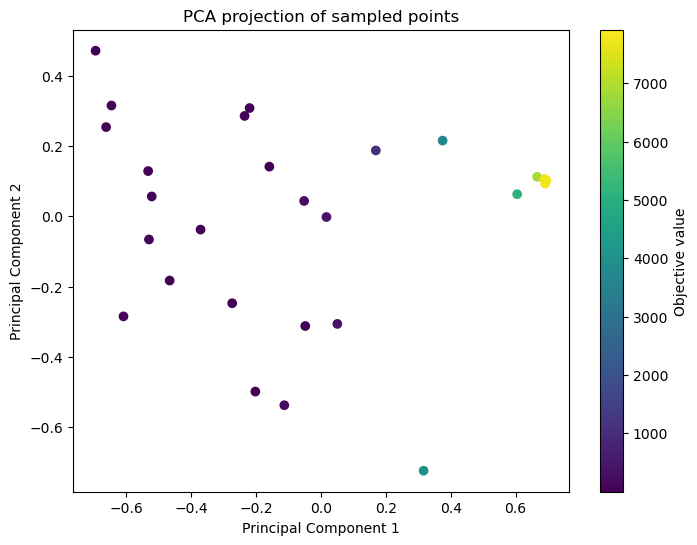

In [13]:
#Create a PCA plot to visulize patterns in the data  
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.colorbar(scatter, label="Objective value")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA projection of sampled points")
plt.show()

In [69]:
#Define GP hyperparameters and make a grid / generate random candidate points for acqusition optimisation

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

#hyperparamters for GP surrogate model and acqusition function 
rbf_lengthscale = 0.5
noise_assumption = 0.01
xi = 0.001

# number of random candidate points
n_candidates = 5000

# sample uniformly from [0, 1]^5
X_candidates = np.random.rand(n_candidates, 4)


In [72]:
#Fit the GP to current data 

kernel = (C(1.0, (1e-2, 1e2)) * RBF(length_scale=[0.5, 0.5, 0.5, 0.5], length_scale_bounds=(0.1, 5))
    + WhiteKernel(noise_level=0.01 , noise_level_bounds=(1e-5, 0.05)))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=20, random_state=0)
gp.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=[0.5, 0.5, 0.5, 0.5]) + WhiteKernel(noise_level=0.01),
                         n_restarts_optimizer=20, normalize_y=True,
                         random_state=0)

In [74]:
#Setting up and running acqusition function 

from scipy.stats import norm
import numpy as np

#Expected Improvement 

#Write the function
def expected_improvement(mu, sigma, y_best, xi=0.0):
    sigma = np.maximum(sigma, 1e-12)
    imp = mu - y_best - xi
    Z = imp / sigma
    return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

# Predict GP on candidate set
mu, std = gp.predict(X_candidates, return_std=True)

# Best observed so far (maximization)
y_best = float(np.max(y))

# Compute EI and use it to select next point 
ei = expected_improvement(mu, std, y_best, xi=xi)  # use your xi
ix = int(np.argmax(ei))
x_next = X_candidates[ix]
print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f},{x_next[2]:.6f},{x_next[3]:.6f}) ")


x_next = (0.996079, 0.849409,0.998724,0.359796) 


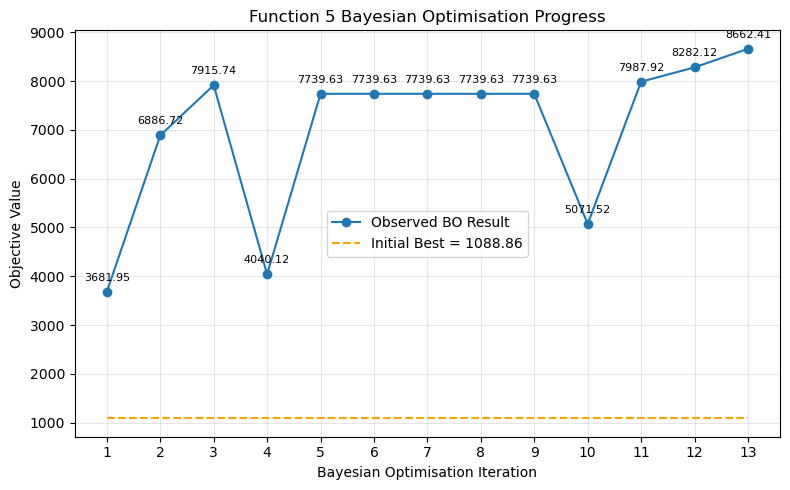

In [32]:
# Plot a graph to track function_5 Bayesian Optimisation progress 

#Intial y_best existing in origional dataset 
INITIAL_BEST_Y = 1088.859618  

# Load my live CSV data file 
df_plot = pd.read_csv(csv_path)
df_plot["y"] = pd.to_numeric(df_plot["y"], errors="coerce")

# Select Bayesian Optimisation data from existing dataset and assign them indexes for plotting
bo = df_plot.tail(13).copy()
bo["iteration"] = range(1, len(bo) + 1)

x = bo["iteration"]
y = bo["y"]

# Flat baseline using your manual value
baseline = np.full(len(y), INITIAL_BEST_Y)

# Plot the graph 
plt.figure(figsize=(8, 5))

plt.plot(x, y, marker="o", label="Observed BO Result")
plt.plot(x, baseline, linestyle="--", color="orange", label=f"Initial Best = {INITIAL_BEST_Y:.2f}")

# Labels on points
for i, val in zip(x, y):
    plt.annotate(f"{val:.2f}", (i, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.xlabel("Bayesian Optimisation Iteration")
plt.ylabel("Objective Value")
plt.title("Function 5 Bayesian Optimisation Progress")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("function_5_bo_progress.png", dpi=300, bbox_inches="tight")
plt.show()